# Correlation, Multicollinearity & Feature Selection

Understanding relationships between variables is **crucial** before building any ML model.

This notebook covers:
- **A** — What is Correlation?
- **B** — Types of Correlation (Pearson, Spearman, Kendall)
- **C** — Visualizing Correlation
- **D** — The Third Factor Problem (Confounding Variables)
- **E** — Multicollinearity — The Silent Model Killer
- **F** — Detecting Multicollinearity (VIF)
- **G** — Feature Selection Using Correlation Matrix
- **H** — Practical Workflow

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded!")

Libraries loaded!


---
## A — What is Correlation?

**Correlation** measures how two variables move together.

| Correlation Value | Meaning |
|-------------------|----------|
| +1.0 | Perfect positive — when X goes up, Y goes up |
| +0.7 to +0.9 | Strong positive |
| +0.4 to +0.6 | Moderate positive |
| -0.3 to +0.3 | Weak or no correlation |
| -0.4 to -0.6 | Moderate negative |
| -0.7 to -0.9 | Strong negative |
| -1.0 | Perfect negative — when X goes up, Y goes down |

### The Formula (Pearson)

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Essentially: how much do X and Y deviate from their means **together**?

In [2]:
# Generate examples of different correlations
n = 100

# Perfect positive correlation
x = np.linspace(0, 10, n)
y_perfect_pos = 2 * x + 1

# Strong positive correlation (with noise)
y_strong_pos = 2 * x + 1 + np.random.randn(n) * 2

# No correlation
y_no_corr = np.random.randn(n) * 5

# Negative correlation
y_negative = -1.5 * x + 15 + np.random.randn(n) * 2

# Calculate correlations
print("Pearson Correlation Coefficients:")
print(f"  Perfect positive:  r = {np.corrcoef(x, y_perfect_pos)[0,1]:.4f}")
print(f"  Strong positive:   r = {np.corrcoef(x, y_strong_pos)[0,1]:.4f}")
print(f"  No correlation:    r = {np.corrcoef(x, y_no_corr)[0,1]:.4f}")
print(f"  Negative:          r = {np.corrcoef(x, y_negative)[0,1]:.4f}")

Pearson Correlation Coefficients:
  Perfect positive:  r = 1.0000
  Strong positive:   r = 0.9564
  No correlation:    r = 0.0062
  Negative:          r = -0.9048


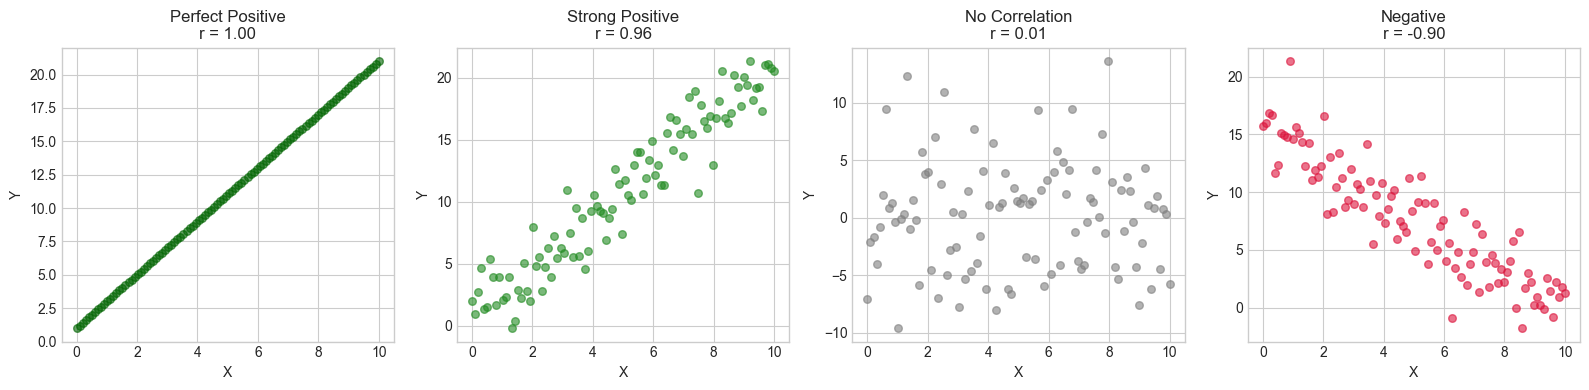

In [3]:
# Visualize different correlations
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

data = [
    (y_perfect_pos, "Perfect Positive\nr = 1.00", 'darkgreen'),
    (y_strong_pos, f"Strong Positive\nr = {np.corrcoef(x, y_strong_pos)[0,1]:.2f}", 'forestgreen'),
    (y_no_corr, f"No Correlation\nr = {np.corrcoef(x, y_no_corr)[0,1]:.2f}", 'gray'),
    (y_negative, f"Negative\nr = {np.corrcoef(x, y_negative)[0,1]:.2f}", 'crimson')
]

for ax, (y, title, color) in zip(axes, data):
    ax.scatter(x, y, alpha=0.6, color=color, s=30)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.tight_layout()
plt.show()

---
## B — Types of Correlation

Not all relationships are linear. Different correlation methods capture different patterns.

| Method | What it Captures | When to Use |
|--------|-----------------|-------------|
| **Pearson** | Linear relationships | Continuous data, normally distributed |
| **Spearman** | Monotonic relationships (rank-based) | Ordinal data, non-linear but monotonic |
| **Kendall** | Concordance between rankings | Small samples, robust to outliers |

### Key Insight
- Pearson correlation = 0 does **NOT** mean no relationship!
- It only means no **linear** relationship.

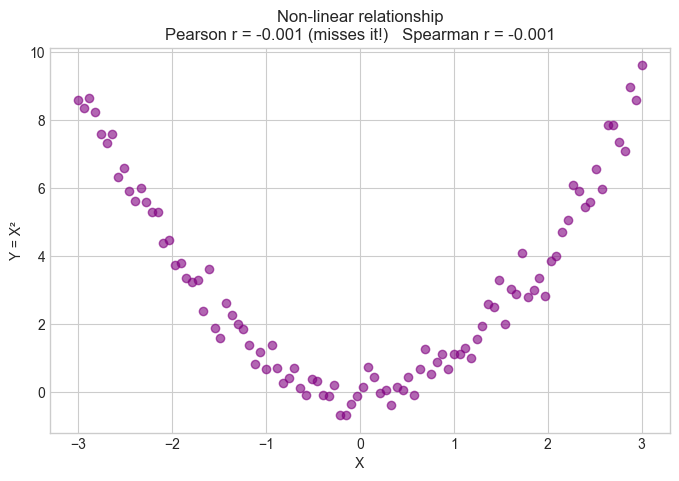


Pearson says correlation ≈ 0, but there's clearly a strong pattern!
This is why you must VISUALIZE your data, not just compute numbers.


In [4]:
# Example: non-linear relationship where Pearson fails
x_nonlin = np.linspace(-3, 3, 100)
y_nonlin = x_nonlin ** 2 + np.random.randn(100) * 0.5  # parabola

pearson_r, _ = stats.pearsonr(x_nonlin, y_nonlin)
spearman_r, _ = stats.spearmanr(x_nonlin, y_nonlin)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_nonlin, y_nonlin, alpha=0.6, color='purple')
ax.set_title(f'Non-linear relationship\nPearson r = {pearson_r:.3f} (misses it!)   Spearman r = {spearman_r:.3f}')
ax.set_xlabel('X')
ax.set_ylabel('Y = X²')
plt.show()

print("\nPearson says correlation ≈ 0, but there's clearly a strong pattern!")
print("This is why you must VISUALIZE your data, not just compute numbers.")

In [5]:
# Comparing correlation methods on monotonic but non-linear data
x_mono = np.linspace(1, 10, 50)
y_mono = np.log(x_mono) + np.random.randn(50) * 0.1  # log relationship

pearson, _ = stats.pearsonr(x_mono, y_mono)
spearman, _ = stats.spearmanr(x_mono, y_mono)
kendall, _ = stats.kendalltau(x_mono, y_mono)

print("Monotonic non-linear relationship (y = log(x)):")
print(f"  Pearson:  {pearson:.4f}")
print(f"  Spearman: {spearman:.4f}  ← captures the monotonic trend better")
print(f"  Kendall:  {kendall:.4f}")

Monotonic non-linear relationship (y = log(x)):
  Pearson:  0.9285
  Spearman: 0.9689  ← captures the monotonic trend better
  Kendall:  0.8645


---
## C — Visualizing Correlation: The Correlation Matrix

When you have multiple features, compute pairwise correlations and display them in a **heatmap**.

This is your first step in any ML project!

In [6]:
# Create a realistic dataset
n = 500

# Independent base variables
study_hours = np.random.uniform(1, 10, n)
sleep_hours = np.random.uniform(4, 9, n)
previous_gpa = np.random.uniform(2.0, 4.0, n)

# Derived/correlated variables
attendance = 0.6 * study_hours + 0.3 * previous_gpa + np.random.randn(n) * 0.5
attendance = np.clip(attendance, 0, 10)

# Target: exam score influenced by multiple factors
exam_score = (
    8 * study_hours + 
    3 * sleep_hours + 
    10 * previous_gpa + 
    np.random.randn(n) * 5
)

df = pd.DataFrame({
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'previous_gpa': previous_gpa,
    'attendance': attendance,
    'exam_score': exam_score
})

print(df.head())
print(f"\nShape: {df.shape}")

   study_hours  sleep_hours  previous_gpa  attendance  exam_score
0     9.071096     5.153349      3.448678    6.936875  122.419287
1     5.265655     4.882640      3.156774    3.772353   87.026443
2     7.008020     5.102431      2.548321    5.905957   96.966993
3     2.550879     4.932191      2.158839    2.718203   59.527588
4     2.730601     7.897922      2.171316    2.066095   61.347677

Shape: (500, 5)


In [7]:
# Compute correlation matrix
corr_matrix = df.corr()

print("Correlation Matrix:")
print(corr_matrix.round(3))

Correlation Matrix:
              study_hours  sleep_hours  previous_gpa  attendance  exam_score
study_hours         1.000       -0.052         0.049       0.948       0.919
sleep_hours        -0.052        1.000         0.037      -0.037       0.164
previous_gpa        0.049        0.037         1.000       0.159       0.305
attendance          0.948       -0.037         0.159       1.000       0.897
exam_score          0.919        0.164         0.305       0.897       1.000


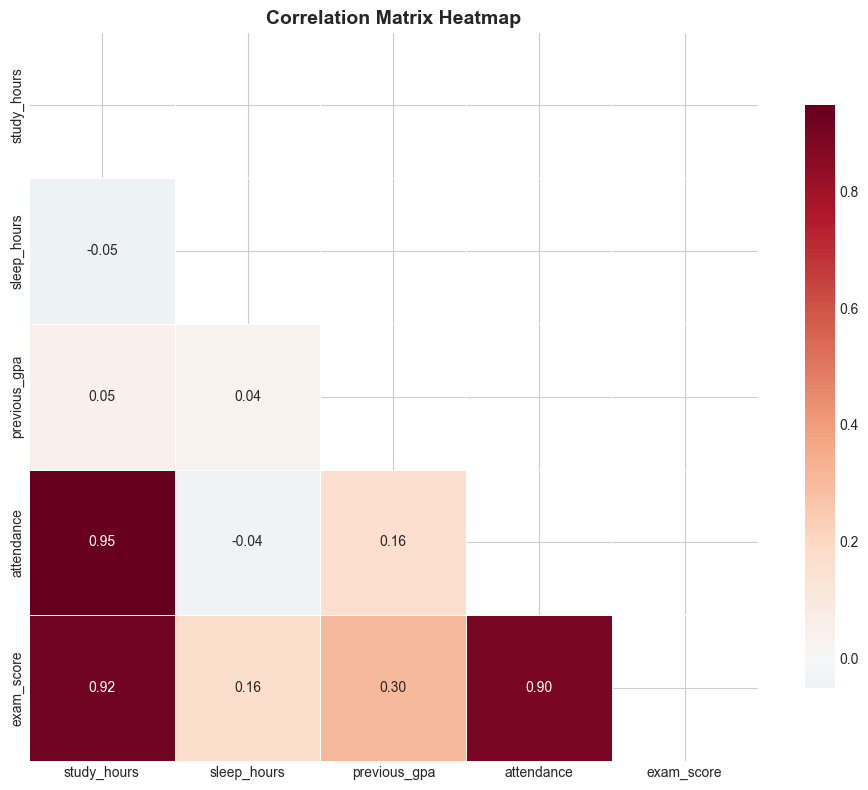


Red = positive correlation, Blue = negative correlation
Darker colors = stronger correlation


In [8]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nRed = positive correlation, Blue = negative correlation")
print("Darker colors = stronger correlation")

---
## D — The Third Factor Problem (Confounding Variables)

### 🚨 CRITICAL CONCEPT: Correlation ≠ Causation

Two variables can be **highly correlated** without one causing the other.

A **third factor (confounding variable)** can create a spurious correlation.

### Classic Examples:

| Correlated Variables | Third Factor (True Cause) |
|---------------------|---------------------------|
| Ice cream sales ↔ Drowning deaths | Summer (hot weather) |
| Shoe size ↔ Reading ability | Age (children grow) |
| Number of firefighters ↔ Fire damage | Fire size |
| Nicholas Cage movies ↔ Pool drownings | Pure coincidence (spurious) |

In [9]:
# Simulate the ice cream / drowning example
np.random.seed(123)
n_months = 120  # 10 years of monthly data

# THE CONFOUNDING VARIABLE: Temperature
month = np.tile(np.arange(1, 13), 10)  # months 1-12, repeated
temperature = 20 + 15 * np.sin((month - 4) * np.pi / 6) + np.random.randn(n_months) * 2

# Both variables are caused by temperature, not each other!
ice_cream_sales = 50 + 3 * temperature + np.random.randn(n_months) * 10
drowning_incidents = 2 + 0.15 * temperature + np.random.randn(n_months) * 1
drowning_incidents = np.maximum(drowning_incidents, 0)

# Correlation between ice cream and drowning
spurious_corr, _ = stats.pearsonr(ice_cream_sales, drowning_incidents)

print(f"Correlation between ice cream sales and drowning: r = {spurious_corr:.3f}")
print("\nThis is HIGH! Does ice cream cause drowning? NO!")
print("Both are caused by the THIRD FACTOR: hot weather (temperature)")

Correlation between ice cream sales and drowning: r = 0.801

This is HIGH! Does ice cream cause drowning? NO!
Both are caused by the THIRD FACTOR: hot weather (temperature)


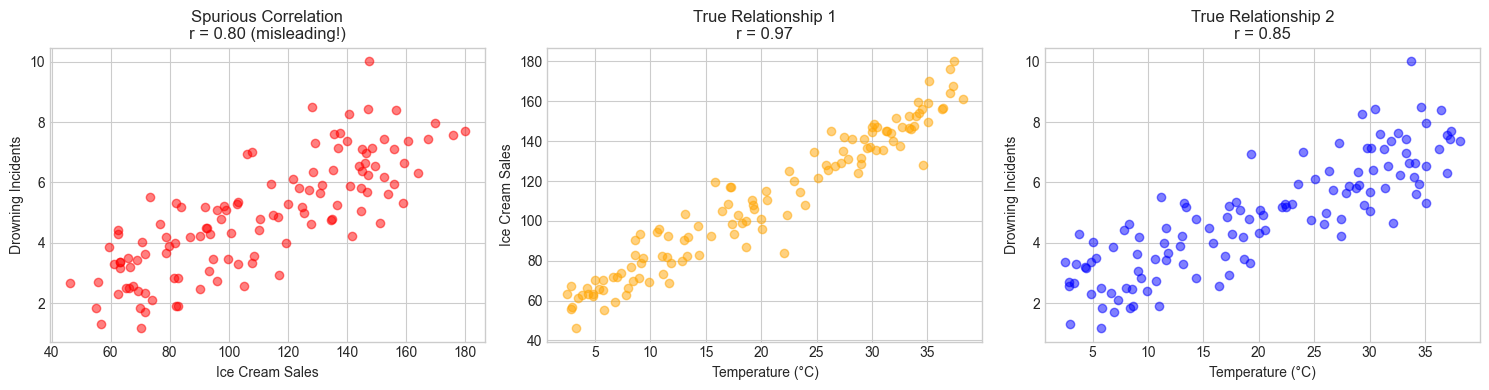


The causal structure:
                    Temperature
                    /         \
                   ↓           ↓
          Ice Cream Sales   Drowning
                   \         /
                    ↘       ↙
               (Spurious correlation)


In [10]:
# Visualize the confounding relationship
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Spurious correlation
axes[0].scatter(ice_cream_sales, drowning_incidents, alpha=0.5, c='red')
axes[0].set_xlabel('Ice Cream Sales')
axes[0].set_ylabel('Drowning Incidents')
axes[0].set_title(f'Spurious Correlation\nr = {spurious_corr:.2f} (misleading!)')

# Plot 2: Real cause - temperature vs ice cream
r1, _ = stats.pearsonr(temperature, ice_cream_sales)
axes[1].scatter(temperature, ice_cream_sales, alpha=0.5, c='orange')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Ice Cream Sales')
axes[1].set_title(f'True Relationship 1\nr = {r1:.2f}')

# Plot 3: Real cause - temperature vs drowning
r2, _ = stats.pearsonr(temperature, drowning_incidents)
axes[2].scatter(temperature, drowning_incidents, alpha=0.5, c='blue')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Drowning Incidents')
axes[2].set_title(f'True Relationship 2\nr = {r2:.2f}')

plt.tight_layout()
plt.show()

print("\nThe causal structure:")
print("                    Temperature")
print("                    /         \\")
print("                   ↓           ↓")
print("          Ice Cream Sales   Drowning")
print("                   \\         /")
print("                    ↘       ↙")
print("               (Spurious correlation)")

In [11]:
# Partial correlation: control for the confounding variable
from scipy.stats import pearsonr

def partial_correlation(x, y, z):
    """
    Calculate partial correlation between x and y, controlling for z.
    This removes the effect of z from both x and y.
    """
    # Regress x on z and get residuals
    slope_xz = np.polyfit(z, x, 1)
    x_residuals = x - np.polyval(slope_xz, z)
    
    # Regress y on z and get residuals
    slope_yz = np.polyfit(z, y, 1)
    y_residuals = y - np.polyval(slope_yz, z)
    
    # Correlation of residuals
    partial_r, _ = pearsonr(x_residuals, y_residuals)
    return partial_r

# Calculate partial correlation (controlling for temperature)
partial_r = partial_correlation(ice_cream_sales, drowning_incidents, temperature)

print("Removing the effect of temperature:")
print(f"  Raw correlation (ice cream ↔ drowning):     r = {spurious_corr:.3f}")
print(f"  Partial correlation (controlling for temp): r = {partial_r:.3f}")
print("\n→ After removing temperature's effect, the correlation nearly disappears!")
print("  This proves temperature was the confounding variable.")

Removing the effect of temperature:
  Raw correlation (ice cream ↔ drowning):     r = 0.801
  Partial correlation (controlling for temp): r = -0.153

→ After removing temperature's effect, the correlation nearly disappears!
  This proves temperature was the confounding variable.


### How to Identify Third Factor Issues

1. **Ask "why?"** — Is there a logical reason for the correlation?
2. **Look for common causes** — What could drive both variables?
3. **Use partial correlation** — Control for suspected confounders
4. **Domain knowledge** — Consult experts in the field
5. **Experimental design** — Only randomized controlled trials prove causation

---
## E — Multicollinearity: The Silent Model Killer

**Multicollinearity** = when two or more features are **highly correlated with each other**.

### Why is this a problem?

| Issue | Explanation |
|-------|-------------|
| **Unstable coefficients** | Small changes in data → wild swings in coefficients |
| **Inflated standard errors** | Coefficients become statistically insignificant |
| **Unreliable feature importance** | Can't tell which feature actually matters |
| **Overfitting** | Model captures noise in the correlation |
| **Interpretation fails** | "If X increases by 1, Y increases by β" becomes meaningless when X and Z always move together |

### Example: Height in inches vs Height in cm
These are perfectly correlated (r = 1). Including both in a model is redundant and harmful.

In [12]:
# Demonstrate multicollinearity problem
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 200

# Create features with multicollinearity
x1 = np.random.randn(n)  # independent feature
x2 = x1 * 0.95 + np.random.randn(n) * 0.1  # highly correlated with x1 (r ≈ 0.99)
x3 = np.random.randn(n)  # independent feature

# True relationship: y depends on x1 and x3, NOT x2
y = 3 * x1 + 2 * x3 + np.random.randn(n) * 0.5

# Calculate correlation
corr_x1_x2 = np.corrcoef(x1, x2)[0, 1]
print(f"Correlation between x1 and x2: r = {corr_x1_x2:.4f}")
print("\nThis is VERY high — multicollinearity present!")

Correlation between x1 and x2: r = 0.9940

This is VERY high — multicollinearity present!


In [13]:
# Compare model WITH vs WITHOUT multicollinearity

# Model 1: With multicollinearity (x1, x2, x3)
X_collinear = np.column_stack([x1, x2, x3])
model_bad = LinearRegression()
model_bad.fit(X_collinear, y)

# Model 2: Without multicollinearity (x1, x3 only)
X_clean = np.column_stack([x1, x3])
model_good = LinearRegression()
model_good.fit(X_clean, y)

print("True coefficients: x1=3, x3=2")
print("\n" + "="*50)
print("Model WITH multicollinearity (x1, x2, x3):")
print(f"  x1 coefficient: {model_bad.coef_[0]:.4f}  (should be ~3)")
print(f"  x2 coefficient: {model_bad.coef_[1]:.4f}  (should be ~0)")
print(f"  x3 coefficient: {model_bad.coef_[2]:.4f}  (should be ~2)")
print("\n" + "="*50)
print("Model WITHOUT multicollinearity (x1, x3):")
print(f"  x1 coefficient: {model_good.coef_[0]:.4f}  (should be ~3)")
print(f"  x3 coefficient: {model_good.coef_[1]:.4f}  (should be ~2)")
print("="*50)
print("\nNotice how the clean model recovers the true coefficients more accurately!")

True coefficients: x1=3, x3=2

Model WITH multicollinearity (x1, x2, x3):
  x1 coefficient: 3.5714  (should be ~3)
  x2 coefficient: -0.5491  (should be ~0)
  x3 coefficient: 2.0588  (should be ~2)

Model WITHOUT multicollinearity (x1, x3):
  x1 coefficient: 3.0444  (should be ~3)
  x3 coefficient: 2.0599  (should be ~2)

Notice how the clean model recovers the true coefficients more accurately!


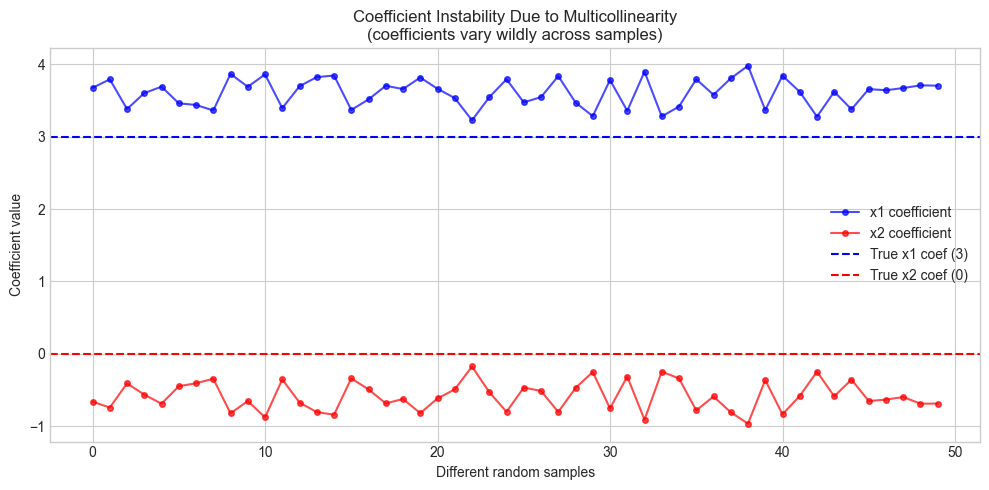

x1 coefficient std: 0.1923
x2 coefficient std: 0.1990

High variance = unreliable coefficients!


In [14]:
# Show coefficient instability with multicollinearity
coefs_x1 = []
coefs_x2 = []

# Train on different random subsets
for seed in range(50):
    np.random.seed(seed)
    indices = np.random.choice(n, size=int(n*0.8), replace=False)
    
    model = LinearRegression()
    model.fit(X_collinear[indices], y[indices])
    coefs_x1.append(model.coef_[0])
    coefs_x2.append(model.coef_[1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coefs_x1, 'b-o', label='x1 coefficient', alpha=0.7, markersize=4)
ax.plot(coefs_x2, 'r-o', label='x2 coefficient', alpha=0.7, markersize=4)
ax.axhline(y=3, color='blue', linestyle='--', label='True x1 coef (3)')
ax.axhline(y=0, color='red', linestyle='--', label='True x2 coef (0)')
ax.set_xlabel('Different random samples')
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Instability Due to Multicollinearity\n(coefficients vary wildly across samples)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"x1 coefficient std: {np.std(coefs_x1):.4f}")
print(f"x2 coefficient std: {np.std(coefs_x2):.4f}")
print("\nHigh variance = unreliable coefficients!")

---
## F — Detecting Multicollinearity: VIF

**VIF (Variance Inflation Factor)** measures how much a feature's variance is "inflated" due to correlation with other features.

$$VIF_j = \frac{1}{1 - R^2_j}$$

Where $R^2_j$ is the R-squared from regressing feature $j$ on all other features.

| VIF Value | Interpretation |
|-----------|----------------|
| 1 | No correlation (ideal) |
| 1-5 | Moderate correlation (usually OK) |
| 5-10 | High correlation (investigate) |
| >10 | Severe multicollinearity (fix it!) |

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    """
    Calculate VIF for all features in a dataframe.
    """
    vif_data = pd.DataFrame()
    vif_data['Feature'] = df.columns
    vif_data['VIF'] = [
        variance_inflation_factor(df.values, i) 
        for i in range(df.shape[1])
    ]
    return vif_data.sort_values('VIF', ascending=False)

# Create dataframe with collinear features
df_collinear = pd.DataFrame({
    'x1': x1,
    'x2': x2,  # highly correlated with x1
    'x3': x3
})

print("VIF for dataset WITH multicollinearity:")
print(calculate_vif(df_collinear))
print("\nVIF > 10 for x1 and x2 — severe multicollinearity!")

VIF for dataset WITH multicollinearity:
  Feature        VIF
1      x2  83.225186
0      x1  83.174031
2      x3   1.017958

VIF > 10 for x1 and x2 — severe multicollinearity!


In [16]:
# After removing x2
df_clean = pd.DataFrame({
    'x1': x1,
    'x3': x3
})

print("VIF after removing the correlated feature (x2):")
print(calculate_vif(df_clean))
print("\nVIF ≈ 1 — no multicollinearity!")

VIF after removing the correlated feature (x2):
  Feature       VIF
1      x3  1.017136
0      x1  1.017136

VIF ≈ 1 — no multicollinearity!


---
## G — Feature Selection Using Correlation Matrix

The correlation matrix is a powerful tool for selecting features:

### Strategy

1. **Keep features highly correlated with target** (these are predictive)
2. **Remove features highly correlated with each other** (redundant, cause multicollinearity)
3. **Set thresholds** (e.g., |r| > 0.8 for inter-feature correlation)

In [17]:
# Create a more complex dataset for feature selection
np.random.seed(42)
n = 500

# Base features (independent)
income = np.random.uniform(30000, 150000, n)
age = np.random.uniform(22, 65, n)
education_years = np.random.uniform(10, 22, n)

# Correlated features (derived)
years_employed = 0.8 * (age - 22) + np.random.randn(n) * 2  # correlated with age
years_employed = np.maximum(years_employed, 0)

monthly_income = income / 12 + np.random.randn(n) * 100  # perfectly correlated with income
annual_expenses = 0.7 * income + np.random.randn(n) * 5000  # correlated with income

# Irrelevant feature
shoe_size = np.random.uniform(6, 13, n)

# Target: savings rate
savings = 0.2 * income - 500 * age + 1000 * education_years + np.random.randn(n) * 5000

df_full = pd.DataFrame({
    'income': income,
    'monthly_income': monthly_income,
    'annual_expenses': annual_expenses,
    'age': age,
    'years_employed': years_employed,
    'education_years': education_years,
    'shoe_size': shoe_size,
    'savings': savings
})

print("Dataset shape:", df_full.shape)
print(df_full.head())

Dataset shape: (500, 8)
          income  monthly_income  annual_expenses        age  years_employed  \
0   74944.814262     6377.112695     46904.080198  52.020954       19.017952   
1  144085.716769    11995.336211    102092.525631  45.052144       23.023600   
2  117839.273017     9607.753928     84978.599855  35.309688        7.868605   
3  101839.018104     8425.802643     76988.057865  56.993186       24.703751   
4   48722.236853     4189.885859     42008.269230  51.443440       25.599893   

   education_years  shoe_size       savings  
0        12.221595   8.271583   9874.764026  
1        16.502811   7.886583  18510.022377  
2        20.475350   7.336486  23610.626986  
3        18.786699  10.862487  11679.854492  
4        19.678734   7.531009  -2309.286695  


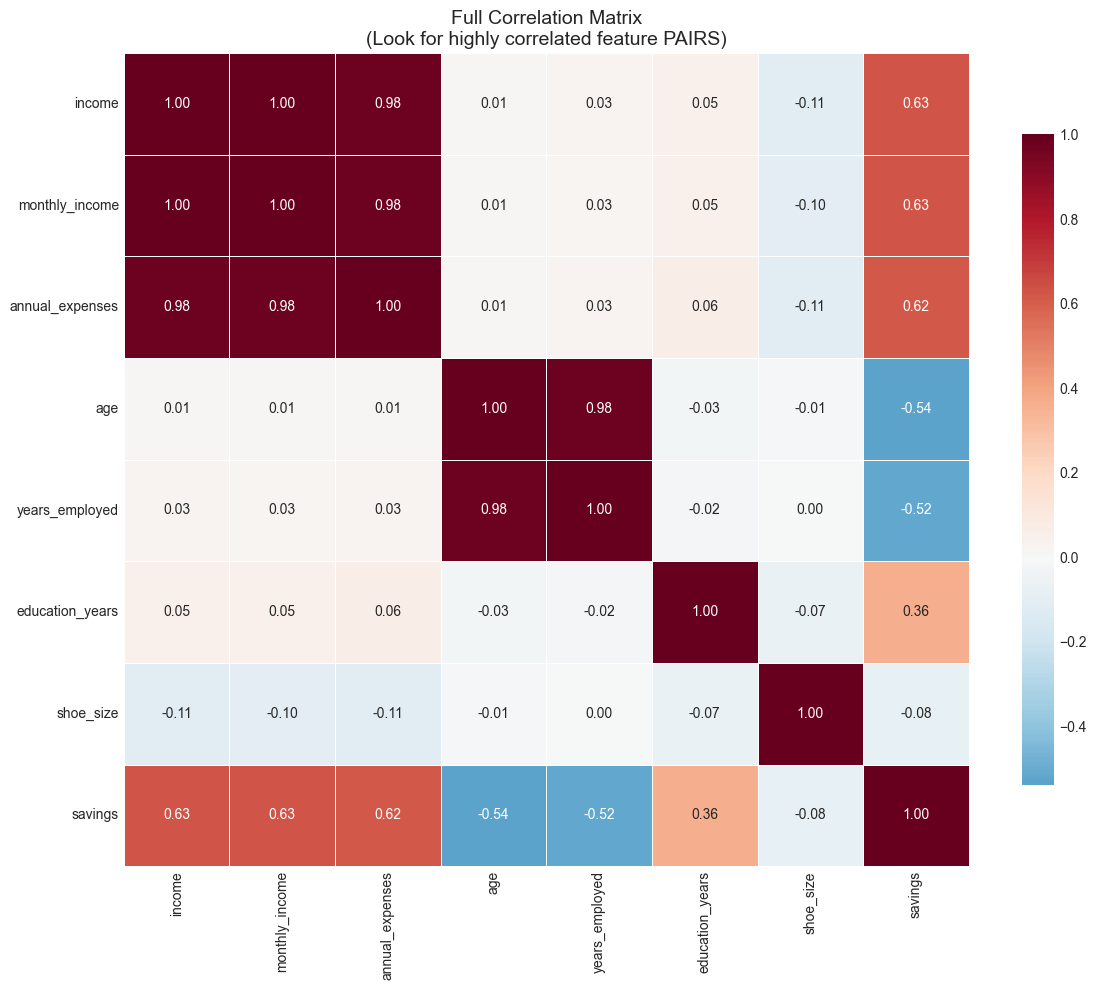

In [18]:
# Full correlation matrix
corr_full = df_full.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_full, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Full Correlation Matrix\n(Look for highly correlated feature PAIRS)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Step 1: Identify correlations with target
target_corr = corr_full['savings'].drop('savings').sort_values(key=abs, ascending=False)

print("Feature correlations with TARGET (savings):")
print("="*45)
for feat, corr in target_corr.items():
    strength = "STRONG" if abs(corr) > 0.5 else "WEAK" if abs(corr) < 0.2 else "MODERATE"
    print(f"  {feat:20s}: {corr:+.3f}  ({strength})")
print("="*45)
print("\n→ Keep features with strong correlation to target")
print("→ shoe_size has no predictive power — candidate for removal")

Feature correlations with TARGET (savings):
  income              : +0.627  (STRONG)
  monthly_income      : +0.626  (STRONG)
  annual_expenses     : +0.621  (STRONG)
  age                 : -0.538  (STRONG)
  years_employed      : -0.515  (STRONG)
  education_years     : +0.359  (MODERATE)
  shoe_size           : -0.077  (WEAK)

→ Keep features with strong correlation to target
→ shoe_size has no predictive power — candidate for removal


In [20]:
def find_highly_correlated_pairs(corr_matrix, threshold=0.8):
    """
    Find pairs of features with correlation above threshold.
    Returns list of (feature1, feature2, correlation) tuples.
    """
    pairs = []
    cols = corr_matrix.columns.tolist()
    
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            corr = corr_matrix.iloc[i, j]
            if abs(corr) >= threshold:
                pairs.append((cols[i], cols[j], corr))
    
    return sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

# Step 2: Find highly correlated feature pairs
features_only = df_full.drop(columns=['savings'])
corr_features = features_only.corr()

high_corr_pairs = find_highly_correlated_pairs(corr_features, threshold=0.8)

print("Highly correlated feature PAIRS (|r| > 0.8):")
print("="*55)
for f1, f2, corr in high_corr_pairs:
    print(f"  {f1:20s} ↔ {f2:20s}: r = {corr:+.3f}")
print("="*55)
print("\n→ These pairs contain REDUNDANT information")
print("→ Keep ONE from each pair, remove the other")

Highly correlated feature PAIRS (|r| > 0.8):
  income               ↔ monthly_income      : r = +0.999
  income               ↔ annual_expenses     : r = +0.981
  monthly_income       ↔ annual_expenses     : r = +0.980
  age                  ↔ years_employed      : r = +0.980

→ These pairs contain REDUNDANT information
→ Keep ONE from each pair, remove the other


In [21]:
def select_features_by_correlation(df, target_col, 
                                    target_threshold=0.1,
                                    feature_threshold=0.8):
    """
    Automated feature selection based on correlation.
    
    Rules:
    1. Remove features with |correlation with target| < target_threshold
    2. For highly correlated pairs, keep the one with higher target correlation
    """
    features = [col for col in df.columns if col != target_col]
    corr_matrix = df.corr()
    
    # Get correlation with target
    target_corr = corr_matrix[target_col].drop(target_col)
    
    # Step 1: Remove features weakly correlated with target
    selected = [f for f in features if abs(target_corr[f]) >= target_threshold]
    removed_weak = set(features) - set(selected)
    
    print(f"Removed (weak target correlation): {removed_weak}")
    
    # Step 2: Handle highly correlated feature pairs
    removed_redundant = set()
    
    for i in range(len(selected)):
        if selected[i] in removed_redundant:
            continue
        for j in range(i+1, len(selected)):
            if selected[j] in removed_redundant:
                continue
            
            f1, f2 = selected[i], selected[j]
            inter_corr = corr_matrix.loc[f1, f2]
            
            if abs(inter_corr) >= feature_threshold:
                # Remove the one with lower correlation to target
                if abs(target_corr[f1]) >= abs(target_corr[f2]):
                    removed_redundant.add(f2)
                    print(f"Removed {f2} (redundant with {f1}, r={inter_corr:.2f})")
                else:
                    removed_redundant.add(f1)
                    print(f"Removed {f1} (redundant with {f2}, r={inter_corr:.2f})")
    
    final_features = [f for f in selected if f not in removed_redundant]
    return final_features

print("Automated Feature Selection")
print("="*50)
selected_features = select_features_by_correlation(
    df_full, 
    target_col='savings',
    target_threshold=0.1,
    feature_threshold=0.8
)
print("="*50)
print(f"\nFinal selected features: {selected_features}")

Automated Feature Selection
Removed (weak target correlation): {'shoe_size'}
Removed monthly_income (redundant with income, r=1.00)
Removed annual_expenses (redundant with income, r=0.98)
Removed years_employed (redundant with age, r=0.98)

Final selected features: ['income', 'age', 'education_years']


In [22]:
# Compare model performance: all features vs selected features
from sklearn.metrics import r2_score, mean_absolute_error

X_all = df_full.drop(columns=['savings'])
X_selected = df_full[selected_features]
y = df_full['savings']

# Split
X_all_train, X_all_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)
X_sel_train, X_sel_test = X_all_train[selected_features], X_all_test[selected_features]

# Model with ALL features
model_all = LinearRegression()
model_all.fit(X_all_train, y_train)
y_pred_all = model_all.predict(X_all_test)

# Model with SELECTED features
model_sel = LinearRegression()
model_sel.fit(X_sel_train, y_train)
y_pred_sel = model_sel.predict(X_sel_test)

print("Model Comparison:")
print("="*55)
print(f"{'Metric':<15} {'All Features (7)':<20} {'Selected ({0})':<20}".format(len(selected_features)))
print("-"*55)
print(f"{'R² Score':<15} {r2_score(y_test, y_pred_all):<20.4f} {r2_score(y_test, y_pred_sel):<20.4f}")
print(f"{'MAE':<15} {mean_absolute_error(y_test, y_pred_all):<20.2f} {mean_absolute_error(y_test, y_pred_sel):<20.2f}")
print("="*55)
print("\nSelected features perform similarly but with FEWER features!")
print("Simpler model = more interpretable, less prone to overfitting")

Model Comparison:
Metric          All Features (7)     Selected (3)      
-------------------------------------------------------
R² Score        0.7821               0.7850              
MAE             4256.23              4244.92             

Selected features perform similarly but with FEWER features!
Simpler model = more interpretable, less prone to overfitting


In [23]:
# Check VIF before and after
print("VIF — Before feature selection:")
print(calculate_vif(X_all))

print("\nVIF — After feature selection:")
print(calculate_vif(X_selected))

VIF — Before feature selection:
           Feature          VIF
0           income  7490.928644
1   monthly_income  7128.426875
2  annual_expenses   194.116064
3              age   120.756824
4   years_employed    40.692271
5  education_years    18.349890
6        shoe_size    18.340771

VIF — After feature selection:
           Feature        VIF
2  education_years  10.580592
1              age   8.903746
0           income   6.402553


---
## H — Practical Workflow Summary

### Step-by-Step Feature Selection Process

```
1. COMPUTE correlation matrix
        ↓
2. VISUALIZE with heatmap
        ↓
3. CHECK correlations with TARGET
   → Remove features with |r| < 0.1 (no predictive power)
        ↓
4. FIND highly correlated feature PAIRS
   → Flag pairs with |r| > 0.8
        ↓
5. FOR each pair: KEEP one, REMOVE one
   → Keep the one with higher target correlation
   → Or use domain knowledge to decide
        ↓
6. VERIFY with VIF
   → All VIF < 10? Good to go!
   → Still high? Remove more features
        ↓
7. TRAIN model and EVALUATE
```

### Key Thresholds

| What | Threshold | Action |
|------|-----------|--------|
| Target correlation | |r| < 0.1 | Remove feature |
| Feature-feature correlation | |r| > 0.8 | Remove one from pair |
| VIF | > 10 | Severe multicollinearity, investigate |
| VIF | > 5 | Moderate, consider removing |

In [24]:
def correlation_feature_selection_report(df, target_col):
    """
    Generate a comprehensive correlation-based feature selection report.
    """
    print("=" * 60)
    print("CORRELATION-BASED FEATURE SELECTION REPORT")
    print("=" * 60)
    
    features = [col for col in df.columns if col != target_col]
    corr_matrix = df.corr()
    
    # 1. Target correlations
    print("\n[1] CORRELATIONS WITH TARGET")
    print("-" * 40)
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(key=abs, ascending=False)
    for feat, corr in target_corr.items():
        status = "✓ KEEP" if abs(corr) >= 0.1 else "✗ DROP"
        print(f"  {feat:20s}: {corr:+.3f}  {status}")
    
    # 2. High inter-feature correlations
    print("\n[2] HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)")
    print("-" * 40)
    feature_corr = df[features].corr()
    pairs = find_highly_correlated_pairs(feature_corr, 0.8)
    if pairs:
        for f1, f2, corr in pairs:
            rec = f1 if abs(target_corr[f1]) >= abs(target_corr[f2]) else f2
            drop = f2 if rec == f1 else f1
            print(f"  {f1} ↔ {f2}: r={corr:+.2f}")
            print(f"     → KEEP {rec}, DROP {drop}")
    else:
        print("  None found — no multicollinearity issues!")
    
    # 3. VIF
    print("\n[3] VARIANCE INFLATION FACTOR (VIF)")
    print("-" * 40)
    vif_df = calculate_vif(df[features])
    for _, row in vif_df.iterrows():
        status = "⚠️  HIGH" if row['VIF'] > 10 else "⚡ MODERATE" if row['VIF'] > 5 else "✓ OK"
        print(f"  {row['Feature']:20s}: VIF = {row['VIF']:.2f}  {status}")
    
    print("\n" + "=" * 60)
    print("END OF REPORT")
    print("=" * 60)

# Generate report
correlation_feature_selection_report(df_full, 'savings')

CORRELATION-BASED FEATURE SELECTION REPORT

[1] CORRELATIONS WITH TARGET
----------------------------------------
  income              : +0.627  ✓ KEEP
  monthly_income      : +0.626  ✓ KEEP
  annual_expenses     : +0.621  ✓ KEEP
  age                 : -0.538  ✓ KEEP
  years_employed      : -0.515  ✓ KEEP
  education_years     : +0.359  ✓ KEEP
  shoe_size           : -0.077  ✗ DROP

[2] HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)
----------------------------------------
  income ↔ monthly_income: r=+1.00
     → KEEP income, DROP monthly_income
  income ↔ annual_expenses: r=+0.98
     → KEEP income, DROP annual_expenses
  monthly_income ↔ annual_expenses: r=+0.98
     → KEEP monthly_income, DROP annual_expenses
  age ↔ years_employed: r=+0.98
     → KEEP age, DROP years_employed

[3] VARIANCE INFLATION FACTOR (VIF)
----------------------------------------
  income              : VIF = 7490.93  ⚠️  HIGH
  monthly_income      : VIF = 7128.43  ⚠️  HIGH
  annual_expenses     : VIF = 194.1

---
## 🏁 Summary — Key Takeaways

| Concept | Key Point |
|---------|----------|
| **Correlation** | Measures linear relationship (-1 to +1) |
| **Pearson vs Spearman** | Pearson for linear, Spearman for monotonic/ranked |
| **Third Factor** | Correlation ≠ Causation! Look for confounding variables |
| **Multicollinearity** | High feature-feature correlation breaks model coefficients |
| **VIF** | Use VIF > 10 as threshold for severe multicollinearity |
| **Feature Selection** | Keep high target correlation, remove high inter-feature correlation |

### Remember:
1. **Always visualize** — heatmaps reveal patterns numbers miss
2. **Question causation** — ask "what third factor could explain this?"
3. **Check VIF** — before trusting your model's coefficients
4. **Less is more** — simpler models with fewer features are often better

### What's Next?
- **Ridge/Lasso Regression** — handles multicollinearity via regularization
- **PCA** — reduces correlated features to uncorrelated components
- **Feature Engineering** — creating better features from existing ones